In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sb

In [2]:
df = pd.read_csv("data/celsius_a_fahrenheit.csv")
df.head()

celcius = np.array(df['Celsius'], dtype=float)
farenheit = np.array(df['Fahrenheit'], dtype=float)

print(f"Celsius: {celcius[:5]}")
print(f"Fahrenheit: {farenheit[:5]}")



Celsius: [-50. -40. -30. -20. -10.]
Fahrenheit: [-58. -40. -22.  -4.  14.]


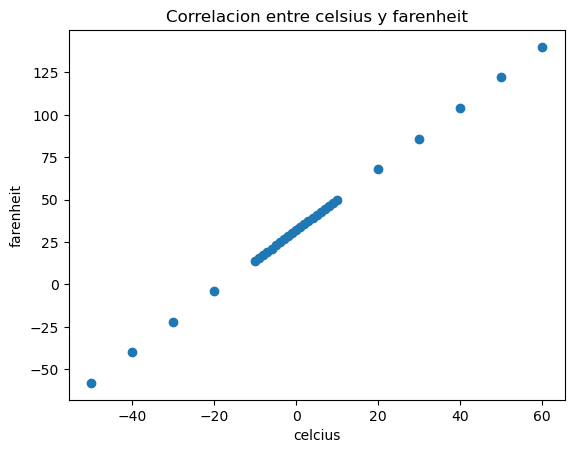

In [3]:
plt.scatter(celcius,farenheit)
plt.title('Correlacion entre celsius y farenheit')
plt.xlabel('celcius')
plt.ylabel('farenheit')

plt.show()


<Axes: xlabel='Celsius', ylabel='Fahrenheit'>

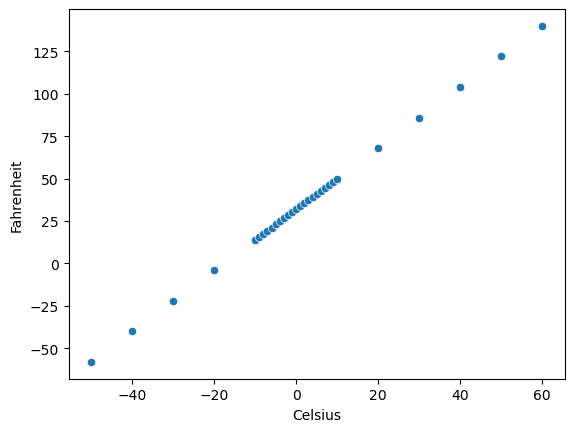

In [4]:
sb.scatterplot(x='Celsius', y='Fahrenheit', data=df)

In [5]:
X_train = celcius
Y_train = farenheit

In [6]:
print("Creando el modelo")
model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=(1,)))
model.add(tf.keras.layers.Dense(units=1))

Creando el modelo


In [7]:
print('Compilando el modelo')
model.compile(
    optimizer=tf.keras.optimizers.Adam(1.0),
    loss='mean_squared_error'
)

Compilando el modelo


In [8]:
print('entrenadno el modelo')
epochs_hist = model.fit(X_train, Y_train, epochs=150)

entrenadno el modelo
Epoch 1/150


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 980ms/step - loss: 3300.0283
Epoch 2/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 1589.2821
Epoch 3/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 909.0051
Epoch 4/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 1015.9413
Epoch 5/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 1364.0535
Epoch 6/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 1489.8638
Epoch 7/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 1325.4629
Epoch 8/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 1014.7822
Epoch 9/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 719.6754
Epoch 10/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 545.3718
Epoch 11/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 517.0657
Epoch 12/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 584.5339
Epoch 13/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 659.6207
Epoch 14/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 671.6374
Epoch 15/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 60

In [9]:
print('evaluando el modelo entrenado')
print('keys:')
print(epochs_hist.history.keys())

evaluando el modelo entrenado
keys:
dict_keys(['loss'])


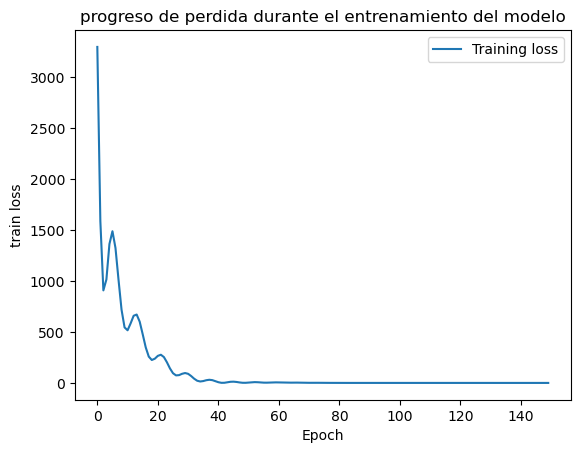

In [10]:
plt.plot(epochs_hist.history['loss'])
plt.title('progreso de perdida durante el entrenamiento del modelo')
plt.xlabel('Epoch')
plt.ylabel('train loss')
plt.legend(['Training loss'])
plt.show()

In [11]:
Temp_C = 100
Temp_C_array = np.array([[Temp_C]])
Temp_F = model.predict(Temp_C_array)
print('temperatura de prediccion: '+str(Temp_F))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
temperatura de prediccion: [[212.03296]]


In [12]:
Temp_F = 9/5 * Temp_C + 32
print('temperatura de ecuacion: '+ str(Temp_F))

temperatura de ecuacion: 212.0


In [13]:
oculta1 = tf.keras.layers.Dense(units=3, input_shape=[1])
oculta2 = tf.keras.layers.Dense(units=3)
salida = tf.keras.layers.Dense(units=1)
modelo = tf.keras.Sequential([oculta1,oculta2,salida])

print(oculta1.get_weights())
print(oculta2.get_weights())
print(salida.get_weights())

[array([[ 0.02909601, -1.182376  , -0.8742763 ]], dtype=float32), array([0., 0., 0.], dtype=float32)]
[array([[-0.46804786, -0.22702432, -0.70524573],
       [ 0.05733824,  0.41461778, -0.6678693 ],
       [-0.85742044,  0.6920066 ,  0.39912295]], dtype=float32), array([0., 0., 0.], dtype=float32)]
[array([[-0.84813106],
       [ 0.36348164],
       [ 0.77617013]], dtype=float32), array([0.], dtype=float32)]


c:\Users\herna\anaconda3\envs\notebooks\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
